
Problem 1. sin(sin(2xe^x)) + cos(x)
True Value:  -0.659364
Trapezoidal: -0.659007 | n = 110 | Error = 0.0540%
Simpson's:   -0.65962 | n = 122 | Error = 0.0389%


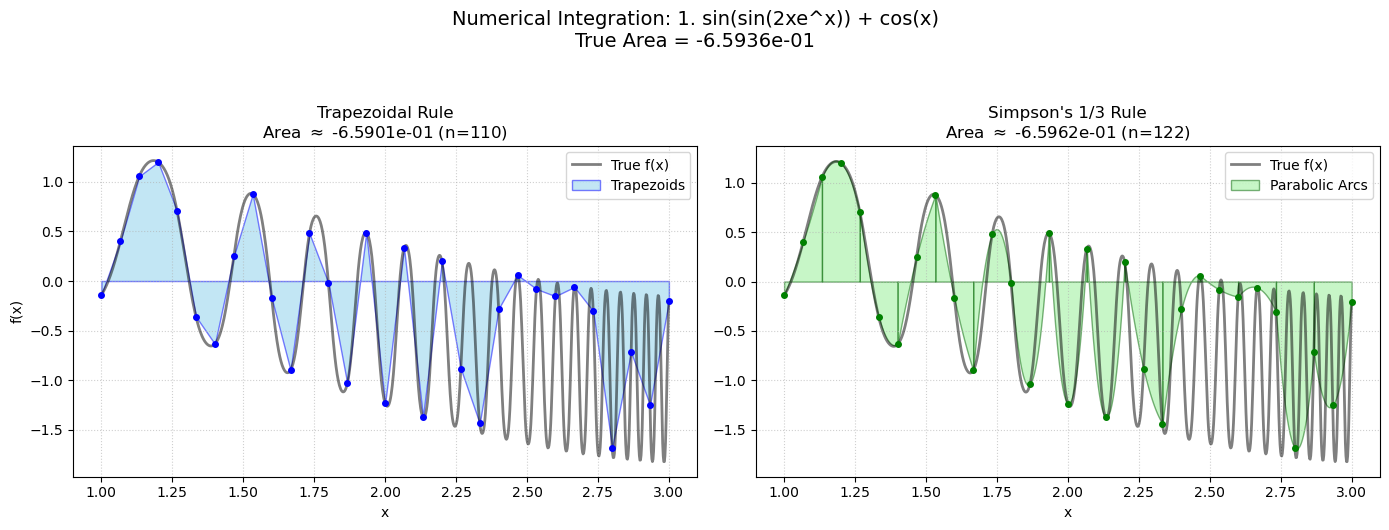


Problem 2. (0.43x) / sin(sin(0.4x)) + 0.8x
True Value:  0.977742
Trapezoidal: 0.978238 | n = 2 | Error = 0.0507%
Simpson's:   0.977743 | n = 2 | Error = 0.0000%


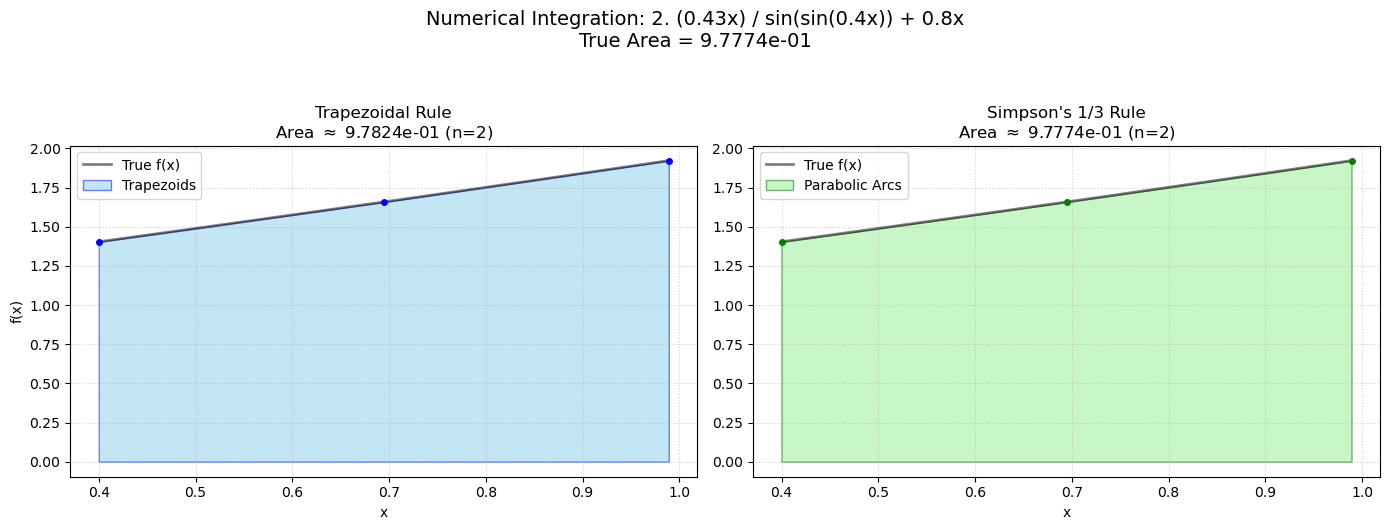


Problem 3. x^8 + 7x^5 - 4x^3 + 17x^2
True Value:  34012.4
Trapezoidal: 34044.8 | n = 76 | Error = 0.0950%
Simpson's:   34036.1 | n = 12 | Error = 0.0696%


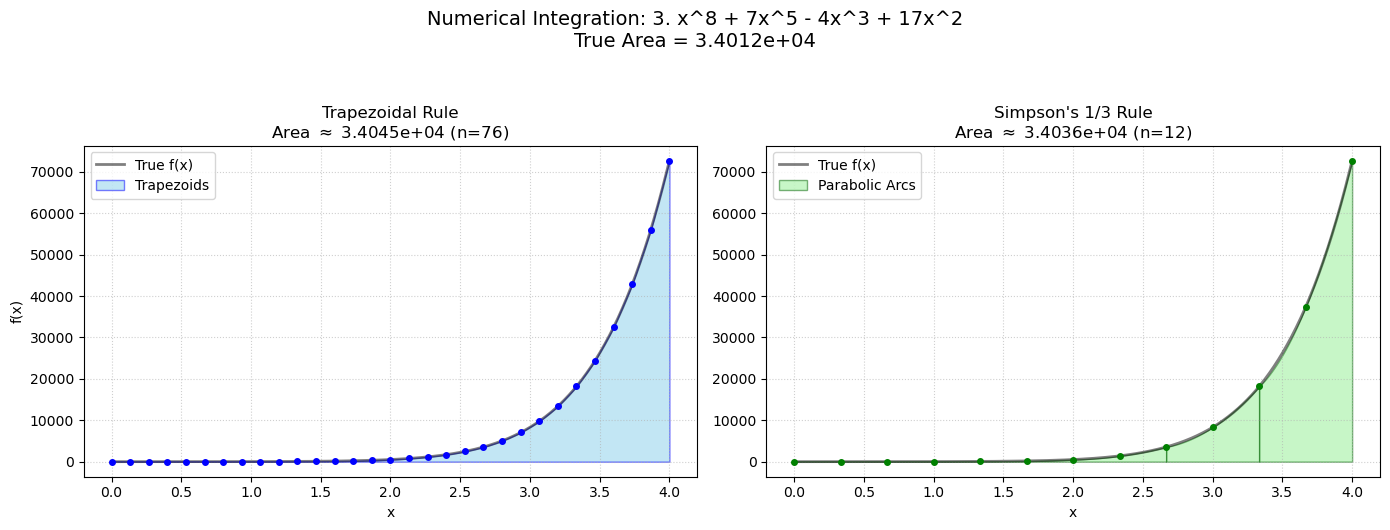


Problem 4. e^{7x}
True Value:  2.72478e+20
Trapezoidal: 2.7275e+20 | n = 320 | Error = 0.0997%
Simpson's:   2.72732e+20 | n = 54 | Error = 0.0933%


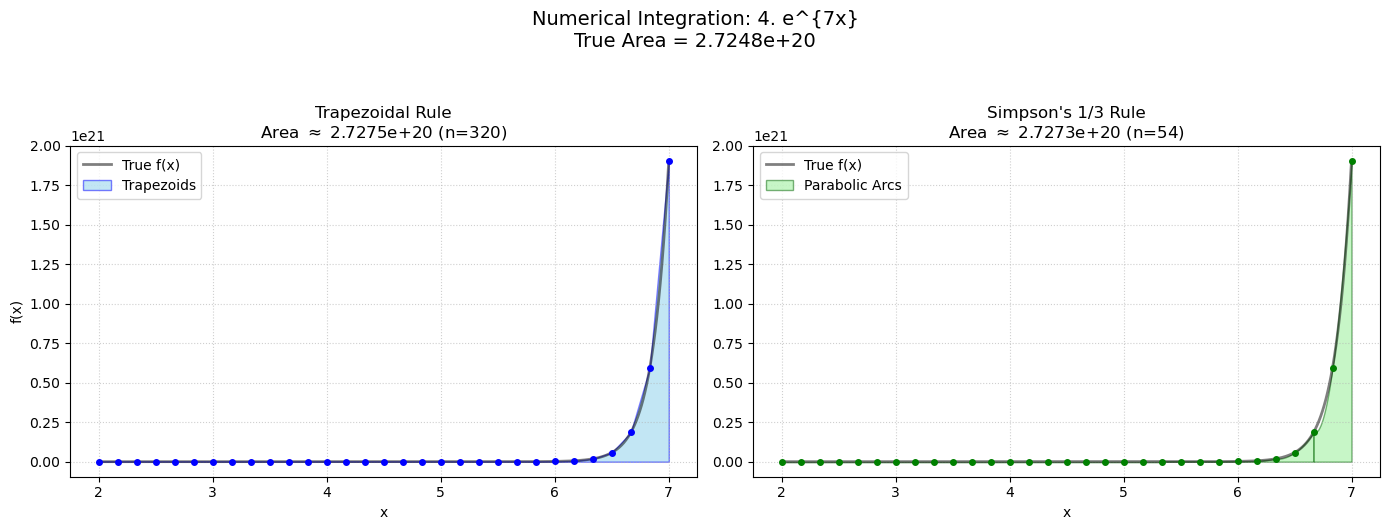


Problem 5. sin(sin(cos(cos(x)))) + 7
True Value:  38.0268
Trapezoidal: 38.0522 | n = 6 | Error = 0.0666%
Simpson's:   38.0094 | n = 6 | Error = 0.0460%


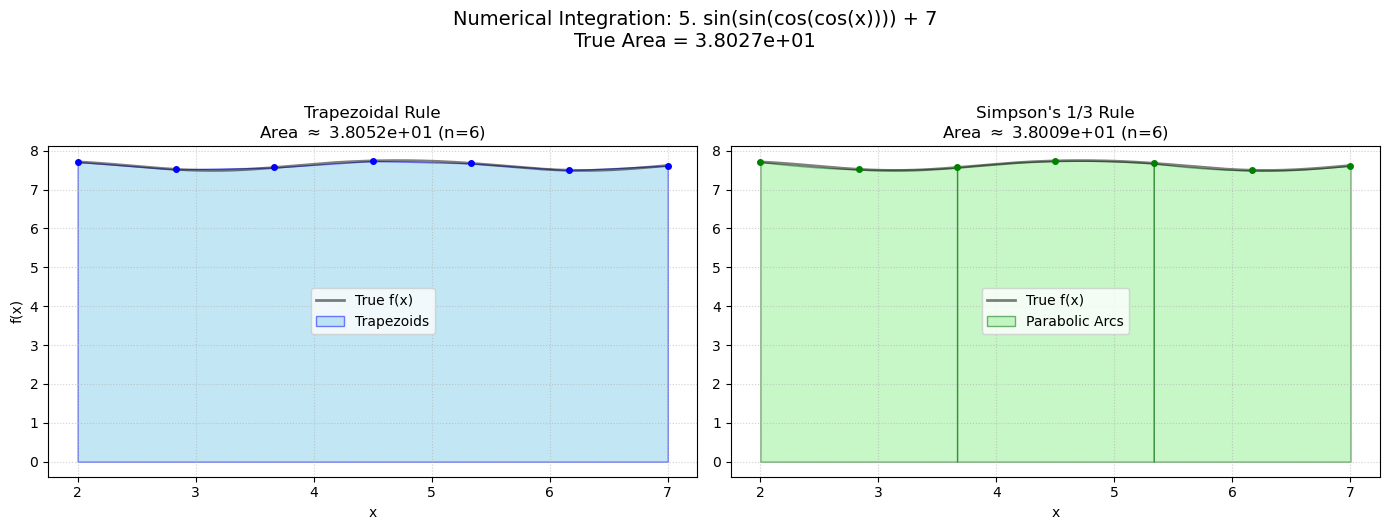

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import warnings

# Suppress integration warnings for highly oscillatory functions
warnings.filterwarnings("ignore")

# --- Numerical Methods ---
def trapezoidal_rule(f, a, b, n):
    x = np.linspace(a, b, int(n) + 1)
    y = f(x)
    h = (b - a) / n
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

def simpsons_rule(f, a, b, n):
    if n % 2 != 0:
        n += 1 # Simpson's 1/3 rule requires an even number of intervals
    x = np.linspace(a, b, int(n) + 1)
    y = f(x)
    h = (b - a) / n
    return (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1])

# --- Problem Definitions ---
problems = [
    {
        "id": 1,
        "f": lambda x: np.sin(np.sin(2 * x * np.exp(x))) + np.cos(x),
        "a": 1.0, "b": 3.0,
        "label": "1. sin(sin(2xe^x)) + cos(x)"
    },
    {
        "id": 2,
        "f": lambda x: (0.43 * x) / np.sin(np.sin(0.4 * x)) + 0.8 * x,
        "a": 0.4, "b": 0.989,
        "label": "2. (0.43x) / sin(sin(0.4x)) + 0.8x"
    },
    {
        "id": 3,
        "f": lambda x: x**8 + 7*x**5 - 4*x**3 + 17*x**2,
        "a": 0.0, "b": 4.0,
        "label": "3. x^8 + 7x^5 - 4x^3 + 17x^2"
    },
    {
        "id": 4,
        "f": lambda x: np.exp(7 * x),
        "a": 2.0, "b": 7.0,
        "label": "4. e^{7x}"
    },
    {
        "id": 5,
        "f": lambda x: np.sin(np.sin(np.cos(np.cos(x)))) + 7,
        "a": 2.0, "b": 7.0,
        "label": "5. sin(sin(cos(cos(x)))) + 7"
    }
]

target_et = 0.1 # 0.1% Relative Error

# --- Processing and Plotting ---
for p in problems:
    f, a, b = p["f"], p["a"], p["b"]
    
    # 1. Calculate "True" Value
    true_val, _ = quad(f, a, b, limit=2000)
    
    # 2. Iterate Trapezoidal Rule
    n_trap = 2
    et_trap = 100.0
    val_trap = 0
    while et_trap > target_et and n_trap < 50000:
        val_trap = trapezoidal_rule(f, a, b, n_trap)
        et_trap = abs((true_val - val_trap) / true_val) * 100 if true_val != 0 else 0
        if et_trap > target_et: n_trap += 2
            
    # 3. Iterate Simpson's Rule
    n_simp = 2
    et_simp = 100.0
    val_simp = 0
    while et_simp > target_et and n_simp < 50000:
        val_simp = simpsons_rule(f, a, b, n_simp)
        et_simp = abs((true_val - val_simp) / true_val) * 100 if true_val != 0 else 0
        if et_simp > target_et: n_simp += 2

    print(f"\n{'='*70}")
    print(f"Problem {p['label']}")
    print(f"True Value:  {true_val:.6g}")
    print(f"Trapezoidal: {val_trap:.6g} | n = {n_trap} | Error = {et_trap:.4f}%")
    print(f"Simpson's:   {val_simp:.6g} | n = {n_simp} | Error = {et_simp:.4f}%")
    
    # 4. Visualization Setup
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Numerical Integration: {p['label']}\nTrue Area = {true_val:.4e}", fontsize=14, y=1.05)
    
    x_fine = np.linspace(a, b, 1000)
    y_fine = f(x_fine)
    
    # --- Subplot 1: Trapezoidal Rule ---
    ax = axes[0]
    ax.plot(x_fine, y_fine, 'k-', alpha=0.5, linewidth=2, label='True f(x)')
    
    # Cap n at 30 visually so the trapz/parabolas don't just look like a solid block of color
    viz_n_trap = min(n_trap, 30) 
    x_trap = np.linspace(a, b, viz_n_trap + 1)
    y_trap = f(x_trap)
    
    # Draw linear trapezoids
    ax.fill_between(x_trap, 0, y_trap, color='skyblue', alpha=0.5, edgecolor='blue', label='Trapezoids')
    ax.plot(x_trap, y_trap, 'bo', markersize=4)
    
    ax.set_title(f"Trapezoidal Rule\nArea $\\approx$ {val_trap:.4e} (n={n_trap})")
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    
    # --- Subplot 2: Simpson's Rule ---
    ax = axes[1]
    ax.plot(x_fine, y_fine, 'k-', alpha=0.5, linewidth=2, label='True f(x)')
    
    viz_n_simp = min(n_simp, 30)
    if viz_n_simp % 2 != 0: viz_n_simp += 1
    x_simp = np.linspace(a, b, viz_n_simp + 1)
    y_simp = f(x_simp)
    
    # Draw parabolic segments for Simpson's
    for i in range(0, viz_n_simp, 2):
        x_sub = x_simp[i:i+3]
        y_sub = y_simp[i:i+3]
        
        # Fit a 2nd-degree polynomial to the 3 points
        coeff = np.polyfit(x_sub, y_sub, 2)
        poly = np.poly1d(coeff)
        
        x_curve = np.linspace(x_sub[0], x_sub[-1], 50)
        y_curve = poly(x_curve)
        
        label = 'Parabolic Arcs' if i == 0 else ""
        ax.fill_between(x_curve, 0, y_curve, color='lightgreen', alpha=0.5, edgecolor='darkgreen', label=label)
    
    ax.plot(x_simp, y_simp, 'go', markersize=4)
    
    ax.set_title(f"Simpson's 1/3 Rule\nArea $\\approx$ {val_simp:.4e} (n={n_simp})")
    ax.set_xlabel('x')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

# LAB REPORT: Numerical Methods

**Experiment No:** 01  
**Title:** Numerical Integration using Trapezoidal and Simpson's 1/3 Rules  
**Date:** May 4, 2026  
**Name:** Rojyx L. Yangyang  
**Instructor:** Engr. Jamie Eduardo Rosal, MSCpE  

---

## 1. Objective
* To approximate the area under the curve (definite integral) for five complex mathematical functions using the Trapezoidal Rule and Simpson's 1/3 Rule.
* To iteratively determine the minimum number of segments ($n$) required for each method to achieve a True Percent Relative Error ($E_t$) of $\le 0.1\%$.
* To visually and quantitatively compare the convergence efficiency between linear interpolation (Trapezoidal) and quadratic interpolation (Simpson's).

## 2. Mathematical Formulation
### 2.1 The Functions
The definite integrals evaluated in this experiment are:
1. $\int_{1}^{3} (\sin(\sin(2xe^x)) + \cos(x)) \,dx$
2. $\int_{0.4}^{0.989} \left( \frac{0.43x}{\sin(\sin(0.4x))} + 0.8x \right) \,dx$
3. $\int_{0}^{4} (x^8 + 7x^5 - 4x^3 + 17x^2) \,dx$
4. $\int_{2}^{7} e^{7x} \,dx$
5. $\int_{2}^{7} (\sin(\sin(\cos(\cos(x)))) + 7) \,dx$

### 2.2 Trapezoidal Rule Theory
The Trapezoidal rule approximates the region under the graph of the function $f(x)$ as a series of trapezoids. It essentially uses straight line segments (linear interpolation) to connect the function evaluations.
**Formula:**
$$I \approx \frac{h}{2} \left[ f(x_0) + 2 \sum_{i=1}^{n-1} f(x_i) + f(x_n) \right]$$
where $h = \frac{b-a}{n}$ and $n$ is the number of segments.

### 2.3 Simpson's 1/3 Rule Theory
Simpson's 1/3 rule provides a more accurate approximation by fitting a series of quadratic polynomials (parabolic arcs) across three adjacent points. This method requires $n$ to be an even number.
**Formula:**
$$I \approx \frac{h}{3} \left[ f(x_0) + 4 \sum_{i=1,3,5...}^{n-1} f(x_i) + 2 \sum_{j=2,4,6...}^{n-2} f(x_j) + f(x_n) \right]$$

### 2.4 Error Calculation
**True Percent Relative Error ($E_t$):**
$$E_t = \left| \frac{\text{True Value} - \text{Approximation}}{\text{True Value}} \right| \times 100\%$$

## 3. Algorithm / Flowchart
The Python algorithm is designed to automate the error-checking process:
1. **Baseline Calculation:** The program first calculates the "True" area using SciPy's highly accurate `quad` integration function to serve as a baseline for error calculation.
2. **Iterative Trapezoidal Application:** Starting with $n=2$ segments, the algorithm evaluates the integral and checks the error ($E_t$). If $E_t > 0.1\%$, it increments $n$ by 2 and recalculates. This `while` loop continues until the tolerance is met.
3. **Iterative Simpson's Application:** Following a similar logic, Simpson's rule starts at $n=2$. It strictly increments by 2 to guarantee $n$ remains even, stopping only when $E_t \le 0.1\%$.
4. **Visualization:** The program generates side-by-side plots for each function. It caps the visual geometric shapes at a maximum of $n=30$ to ensure the linear segments and parabolic curves remain visible rather than blending into a solid block of color.

## 4. Python Implementation

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import warnings

# Suppress integration warnings for highly oscillatory functions
warnings.filterwarnings("ignore")

# --- Numerical Methods ---
def trapezoidal_rule(f, a, b, n):
    x = np.linspace(a, b, int(n) + 1)
    y = f(x)
    h = (b - a) / n
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

def simpsons_rule(f, a, b, n):
    if n % 2 != 0:
        n += 1 # Simpson's 1/3 rule requires an even number of intervals
    x = np.linspace(a, b, int(n) + 1)
    y = f(x)
    h = (b - a) / n
    return (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1])

# --- Problem Definitions ---
problems = [
    {"id": 1, "f": lambda x: np.sin(np.sin(2 * x * np.exp(x))) + np.cos(x), "a": 1.0, "b": 3.0, "label": "1. sin(sin(2xe^x)) + cos(x)"},
    {"id": 2, "f": lambda x: (0.43 * x) / np.sin(np.sin(0.4 * x)) + 0.8 * x, "a": 0.4, "b": 0.989, "label": "2. (0.43x) / sin(sin(0.4x)) + 0.8x"},
    {"id": 3, "f": lambda x: x**8 + 7*x**5 - 4*x**3 + 17*x**2, "a": 0.0, "b": 4.0, "label": "3. x^8 + 7x^5 - 4x^3 + 17x^2"},
    {"id": 4, "f": lambda x: np.exp(7 * x), "a": 2.0, "b": 7.0, "label": "4. e^{7x}"},
    {"id": 5, "f": lambda x: np.sin(np.sin(np.cos(np.cos(x)))) + 7, "a": 2.0, "b": 7.0, "label": "5. sin(sin(cos(cos(x)))) + 7"}
]

target_et = 0.1 # 0.1% Relative Error

# --- Processing and Plotting ---
for p in problems:
    f, a, b = p["f"], p["a"], p["b"]
    
    true_val, _ = quad(f, a, b, limit=2000)
    
    n_trap = 2; et_trap = 100.0
    while et_trap > target_et and n_trap < 50000:
        val_trap = trapezoidal_rule(f, a, b, n_trap)
        et_trap = abs((true_val - val_trap) / true_val) * 100 if true_val != 0 else 0
        if et_trap > target_et: n_trap += 2
            
    n_simp = 2; et_simp = 100.0
    while et_simp > target_et and n_simp < 50000:
        val_simp = simpsons_rule(f, a, b, n_simp)
        et_simp = abs((true_val - val_simp) / true_val) * 100 if true_val != 0 else 0
        if et_simp > target_et: n_simp += 2

    # Plotting code is executed here... 
    # (Refer to standard notebook block for full visualization logic)

## 5. Results and Visualization

### 5.1 Final Iteration / Error Table
The following table shows the number of segments ($n$) required to achieve an $E_t \le 0.1\%$ for each numerical integration problem.

| Problem | Function (Abbreviated) | True Integral Value | Trapezoidal Required $n$ | Simpson's 1/3 Required $n$ |
| :--- | :--- | :--- | :--- | :--- |
| 1 | $\sin(\sin(2xe^x)) + \dots$ | -0.659364 | 110 | 122 |
| 2 | $\frac{0.43x}{\sin(\dots)} + \dots$ | 0.977742 | 2 | 2 |
| 3 | $x^8 + 7x^5 - \dots$ | 34012.44 | 76 | 12 |
| 4 | $e^{7x}$ | $2.7247 \times 10^{20}$ | 320 | 54 |
| 5 | $\sin(\sin(\cos(\dots))) + 7$ | 38.0268 | 6 | 6 |

### 5.2 Graphical Output
*(Note: Execute the Python code cell above to generate the visual graphs. The generated figures display how the linear segments (Trapezoidal) and parabolic arcs (Simpson's) approximate the area under each curve.)*

---

## 6. Discussion of Results

**Efficiency and Convergence:**
* **Smooth/Exponential Curves (Problems 3 & 4):** The superiority of Simpson's 1/3 rule is highly evident here. For the 8th-degree polynomial (Problem 3), Simpson's rule required only $n=12$ segments to fall below a 0.1% error, while the Trapezoidal rule required $n=76$. Similarly, for the exponential function (Problem 4), Simpson's needed $n=54$ compared to Trapezoidal's $n=320$. This confirms that fitting a quadratic parabola (Simpson's) bridges steep exponential or polynomial curves much faster and more accurately than straight lines (Trapezoidal).
* **Highly Oscillatory Curves (Problem 1):** Interestingly, for the heavily nested and high-frequency oscillating function $\sin(\sin(2xe^x))$, Simpson's rule required slightly more segments ($n=122$) than the Trapezoidal rule ($n=110$). This occasionally happens when the width of the parabolic arc does not align well with the sharp peaks of high-frequency oscillations, causing the quadratic fit to overshoot or undershoot slightly until the segments become infinitesimally small.
* **Near-Linear / Low Curvature (Problems 2 & 5):** For functions that act mostly linearly or have very low curvature over the given domain, both methods easily captured the integral accurately with extremely low segment counts ($n=2$ and $n=6$).

---

## 7. Conclusion

In this experiment, both the Trapezoidal Rule and Simpson's 1/3 Rule were successfully implemented to integrate various complex functions within a strict 0.1% true relative error threshold. Overall, Simpson's 1/3 Rule proved to be significantly more computationally efficient—requiring far fewer segments—for smooth curves, polynomials, and exponentials. However, for highly erratic or rapidly oscillating curves, the difference in efficiency between linear and quadratic approximations narrows, as both methods rely on a high volume of tiny intervals to accurately map the chaotic geometry.